# **Project Name**    - Uber Supply Demand Gap Analysis



##### **Project Type**    - EDA
##### **Contribution**    - Individual
##### **Member** - Kashish Sonar


# **Project Summary -**

The primary objective of this Exploratory Data Analysis (EDA) project is to identify the root causes behind the supply-demand gap for Uber rides, specifically focusing on the route between the City and the Airport. Customers frequently face issues such as ride cancellations or "No Cars Available," which directly impacts the company's revenue and customer satisfaction.

The dataset provided contains masked data regarding Uber requests, including driver IDs, pickup points, request timestamps, drop timestamps, and the final status of the ride.

During the initial data wrangling phase, we observed that missing values in the 'Drop timestamp' and 'Driver id' columns were not random errors but systematic indicators of incomplete trips (either 'Cancelled' or 'No Cars Available'). We extracted critical features such as 'Request Hour' and 'Time Slot' (Morning, Evening, etc.) from the timestamp data to perform time-based analysis.

Key Insights Discovered:

Morning Rush (City to Airport): The highest number of cancellations occurs in the morning (5 AM to 9 AM) for rides originating from the City to the Airport. Drivers are likely cancelling these rides because they might not get a return fare from the airport, leading to dead mileage.

Evening Rush (Airport to City): The most significant supply-demand gap due to "No Cars Available" happens in the evening (5 PM to 9 PM) at the Airport. High influx of incoming flights leads to a surge in demand, but there are not enough cabs available at the airport to service these requests.

# **GitHub Link -**

https://github.com/kashish-sonar19/uber_data_analysis

# **Problem Statement**




Uber frequently faces challenges in fulfilling ride requests between the City and the Airport due to an imbalance between customer demand and driver availability. This mismatch leads to a considerable number of ride cancellations and unfulfilled requests. As a result, customers experience delays and inconvenience, while Uber loses potential business opportunities and revenue. Understanding when and where these service gaps occur is essential for improving operational efficiency and customer satisfaction.

#### **Define Your Business Objective?**



The main goal of this analysis is to investigate the factors contributing to ride cancellations and the shortage of available drivers. By examining ride request patterns, peak demand periods, and service outcomes, the study aims to identify critical time slots where the gap between demand and supply is most pronounced. The insights generated from this analysis can help Uber make informed decisions regarding driver deployment, demand management, and service optimization, ultimately enhancing customer experience and maximizing revenue.


# **General Guidelines** : -  

1.   Well-structured, formatted, and commented code is required.
2.   Exception Handling, Production Grade Code & Deployment Ready Code will be a plus. Those students will be awarded some additional credits.
     
     The additional credits will have advantages over other students during Star Student selection.
       
             [ Note: - Deployment Ready Code is defined as, the whole .ipynb notebook should be executable in one go
                       without a single error logged. ]

3.   Each and every logic should have proper comments.
4. You may add as many number of charts you want. Make Sure for each and every chart the following format should be answered.
        

```
# Chart visualization code
```
            

*   Why did you pick the specific chart?
*   What is/are the insight(s) found from the chart?
* Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

5. You have to create at least 20 logical & meaningful charts having important insights.


[ Hints : - Do the Vizualization in  a structured way while following "UBM" Rule.

U - Univariate Analysis,

B - Bivariate Analysis (Numerical - Categorical, Numerical - Numerical, Categorical - Categorical)

M - Multivariate Analysis
 ]





# ***Let's Begin !***

## ***1. Know Your Data***

### Import Libraries

In [2]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore') # to ignore unwanted warning messages


### Dataset Loading

In [5]:
# Load Dataset
df = pd.read_csv("Uber Request Data.csv")

### Dataset First View

In [6]:
# Dataset First Look
df.head()

,Request id,Pickup point,Driver id,Status,Request timestamp,Drop timestamp
0,619,Airport,1.0,Trip Completed,11/7/2016 11:51,11/7/2016 13:00
1,867,Airport,1.0,Trip Completed,11/7/2016 17:57,11/7/2016 18:47
2,1807,City,1.0,Trip Completed,12/7/2016 9:17,12/7/2016 9:58
3,2532,Airport,1.0,Trip Completed,12/7/2016 21:08,12/7/2016 22:03
4,3112,City,1.0,Trip Completed,13-07-2016 08:33:16,13-07-2016 09:25:47


### Dataset Rows & Columns count

In [7]:
# Dataset Rows & Columns count
print(f"Total number of Rows: {df.shape[0]}")
print(f"Total number of Columns: {df.shape[1]}")

Total number of Rows: 6745
Total number of Columns: 6


### Dataset Information

In [8]:
# Dataset Info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6745 entries, 0 to 6744
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Request id         6745 non-null   int64  
 1   Pickup point       6745 non-null   object 
 2   Driver id          4095 non-null   float64
 3   Status             6745 non-null   object 
 4   Request timestamp  6745 non-null   object 
 5   Drop timestamp     2831 non-null   object 
dtypes: float64(1), int64(1), object(4)
memory usage: 316.3+ KB


#### Duplicate Values

In [9]:
# Dataset Duplicate Value Count
duplicate_value_count = df.duplicated().sum()
print(f"Total Duplicate Rows: {duplicate_value_count}")

Total Duplicate Rows: 0


#### Missing Values/Null Values

In [10]:
# Missing Values/Null Values Count
print("Missing values in each column:")
print(df.isnull().sum())

Missing values in each column:
Request id              0
Pickup point            0
Driver id            2650
Status                  0
Request timestamp       0
Drop timestamp       3914
dtype: int64


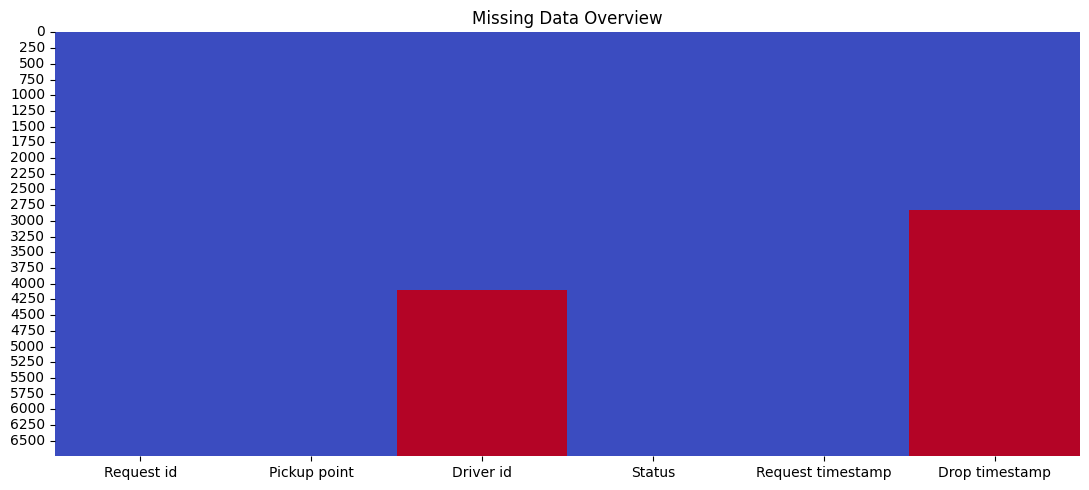

In [11]:
# Visualizing the missing values

plt.figure(figsize=(11, 5))

sns.heatmap(df.isnull(),cmap='coolwarm',cbar=False)

plt.title("Missing Data Overview")
plt.tight_layout()
plt.show()

### What did you know about your dataset?

After conducting an initial examination of the dataset, several important observations were identified. The dataset contains information related to Uber ride requests, including request identifiers, pickup locations, driver assignments, trip statuses, and timestamp details for both ride requests and trip completion.

A review of the dataset showed that there are no duplicate records, indicating that each entry corresponds to a distinct ride request. Missing values were primarily found in the **Driver id** and **Drop timestamp** columns. These missing records are expected because trips marked as **"No Cars Available"** or **"Cancelled"** do not have an assigned driver and therefore do not generate a drop timestamp.

The dataset consists of a combination of categorical and temporal variables. The request and drop timestamps were initially stored as text values and required conversion to datetime format for further analysis. This transformation enables the extraction of useful time-based features such as hours, time slots, and peak demand periods, which are essential for understanding the supply-demand imbalance in Uber services.


## ***2. Understanding Your Variables***

In [15]:
# Dataset Columns
print(df.columns)

Index(['Request id', 'Pickup point', 'Driver id', 'Status',
       'Request timestamp', 'Drop timestamp'],
      dtype='object')


In [14]:
# Dataset Describe
df.describe(include=all)

,Request id,Driver id
count,6745.000000,4095.000000
mean,3384.644922,149.501343
std,1955.099667,86.051994
min,1.000000,1.000000
25%,1691.000000,75.000000
50%,3387.000000,149.000000
75%,5080.000000,224.000000
max,6766.000000,300.000000


### Variables Description

The dataset contains the following variables (columns):

Request id: A unique numerical identifier assigned to each customer's ride request.

Pickup point: The location from where the ride was requested. In this dataset, it only has two categories: 'Airport' and 'City'.

Driver id: A unique numerical identifier for the Uber driver assigned to the trip. This value is missing (NaN) if the trip status is 'Cancelled' or 'No Cars Available'.

Status: The final outcome of the ride request. It has three possible categories: 'Trip Completed', 'Cancelled', and 'No Cars Available'.

Request timestamp: The exact date and time when the customer requested the cab.

Drop timestamp: The exact date and time when the trip was completed and the customer was dropped off. This is missing if the trip was not completed.

### Check Unique Values for each variable.

In [16]:
# Check Unique Values for each variable.
for each_col in df.columns:
    print(f"Unique values in '{each_col}': {df[each_col].nunique()}")

Unique values in 'Request id': 6745
Unique values in 'Pickup point': 2
Unique values in 'Driver id': 300
Unique values in 'Status': 3
Unique values in 'Request timestamp': 5618
Unique values in 'Drop timestamp': 2598


## 3. ***Data Wrangling***

### Data Wrangling Code

In [13]:
# Write your code to make your dataset analysis ready.

# 1. STANDARDIZING DATETIME FORMATS
# Problem: Dates in 'Request timestamp' and 'Drop timestamp' have mixed formats (slashes / and hyphens -).
# Solution: Using pd.to_datetime() to convert these into a uniform pandas datetime format.
# 'dayfirst=True' ensures that dates like 11/7/2016 are read as 11th July, not 7th Nov.
# convert timestamp coloumn into date format
# 'errors="coerce"' means convert date into NaT(Null/Blank)
df['Request timestamp'] = pd.to_datetime(df['Request timestamp'], dayfirst=True, format='mixed', errors='coerce')
df['Drop timestamp'] = pd.to_datetime(df['Drop timestamp'], dayfirst=True, format='mixed', errors='coerce')


# 2. FEATURE ENGINEERING: EXTRACTING DATE AND TIME COMPONENTS
# We need date and specific time components separated to understand the Demand-Supply gap effectively.
df['Request Date'] = df['Request timestamp'].dt.date
df['Request Time'] = df['Request timestamp'].dt.time
df['Request Hour'] = df['Request timestamp'].dt.hour
df['Request Weekday'] = df['Request timestamp'].dt.day_name() # This extracts the name of the day (Monday, Tuesday, etc.)

df['Drop Date'] = df['Drop timestamp'].dt.date
df['Drop Time'] = df['Drop timestamp'].dt.time
df['Drop Hour'] = df['Drop timestamp'].dt.hour


# 3. CREATING TIME SLOTS (Crucial for Business Objective)
# Analyzing raw numeric hours (e.g., 5, 18) can be difficult to interpret for business stakeholders. 
# Therefore, we are categorizing the day into logical parts to clearly visualize the "Early Morning" and "Night" rush.
def assign_time_slot(hour):
    if 4 <= hour < 8:
        return 'Early Morning'
    elif 8 <= hour < 12:
        return 'Morning'
    elif 12 <= hour < 16:
        return 'Afternoon'
    elif 16 <= hour < 20:
        return 'Evening'
    elif 20 <= hour <= 23 or hour == 0:
        return 'Night'
    elif 1 <= hour < 4:
        return 'Late Night'

# Apply the function to create a new categorical column
df['Time Slot'] = df['Request Hour'].apply(assign_time_slot)

# 4. CALCULATING TRIP DURATION (For completed trips only)
# An additional feature to determine the total duration of each completed trip in minutes.
df['Trip Duration (mins)'] = (df['Drop timestamp'] - df['Request timestamp']).dt.total_seconds() / 60

# for handling null values
df['Trip Duration (mins)'] = df['Trip Duration (mins)'].fillna(0)
df['Drop Date'] = df['Drop Date'].fillna('Not Applicable')
df['Drop Time'] = df['Drop Time'].fillna('Not Applicable')
df['Drop Hour'] = df['Drop Hour'].fillna(0)
df['Drop timestamp'] = df['Drop timestamp'].astype(object).fillna('Trip Incomplete')


mask_cancelled = (df['Status'] == 'Cancelled')
df.loc[mask_cancelled, 'Driver id'] = 'Cancelled'
mask_no_cars = (df['Status'] == 'No Cars Available')
df.loc[mask_no_cars, 'Driver id'] = 'No Cars Available'
df.fillna('Not Applicable', inplace=True)

# Displaying the head of the dataset to verify that all new columns are created accurately.
df.head()



,Request id,Pickup point,Driver id,Status,Request timestamp,Drop timestamp,Request Date,Request Time,Request Hour,Request Weekday,Drop Date,Drop Time,Drop Hour,Time Slot,Trip Duration (mins)
0,619,Airport,1.0,Trip Completed,2016-07-11 11:51:00,2016-07-11 13:00:00,2016-07-11,11:51:00,11,Monday,2016-07-11,13:00:00,13.0,Morning,69.000000
1,867,Airport,1.0,Trip Completed,2016-07-11 17:57:00,2016-07-11 18:47:00,2016-07-11,17:57:00,17,Monday,2016-07-11,18:47:00,18.0,Evening,50.000000
2,1807,City,1.0,Trip Completed,2016-07-12 09:17:00,2016-07-12 09:58:00,2016-07-12,09:17:00,9,Tuesday,2016-07-12,09:58:00,9.0,Morning,41.000000
3,2532,Airport,1.0,Trip Completed,2016-07-12 21:08:00,2016-07-12 22:03:00,2016-07-12,21:08:00,21,Tuesday,2016-07-12,22:03:00,22.0,Night,55.000000
4,3112,City,1.0,Trip Completed,2016-07-13 08:33:16,2016-07-13 09:25:47,2016-07-13,08:33:16,8,Wednesday,2016-07-13,09:25:47,9.0,Morning,52.516667


### What all manipulations have you done and insights you found?


Several preprocessing steps were carried out to prepare the dataset for analysis and ensure reliable insights.

**1. Timestamp Conversion**

The **Request timestamp** and **Drop timestamp** columns contained date and time information in different formats. These columns were converted into a standardized datetime format using Pandas, allowing accurate time-based calculations and analysis.

**2. Extraction of Time-Based Features**

To better understand ride request patterns, multiple features were derived from the request timestamp, including:

* Request Date
* Request Time
* Request Hour
* Day of the Week

Among these, **Request Hour** plays a key role in identifying periods of high demand and service shortages.

**3. Time Slot Categorization**

To simplify the analysis of demand patterns throughout the day, ride requests were grouped into broader time intervals such as Early Morning, Morning, Afternoon, Evening, Night, and Late Night. This categorization makes it easier to identify trends and compare ride availability across different periods.

**4. Trip Duration Calculation**

For completed trips, the duration of each ride was calculated by measuring the difference between the request and drop timestamps. This metric helps in understanding trip characteristics and operational efficiency.

### Observation During Data Preparation

During the preprocessing stage, missing values in the **Driver id** and **Drop timestamp** columns were intentionally retained. Further investigation revealed that these missing values are directly associated with ride requests that were either **Cancelled** or marked as **No Cars Available**. Therefore, they represent meaningful business information rather than data quality issues. Preserving these records is important for accurately analyzing service failures and quantifying the supply-demand gap.


## ***4. Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables***

#### Chart - 1 : Overall Trip Status (Univariate Analysis)

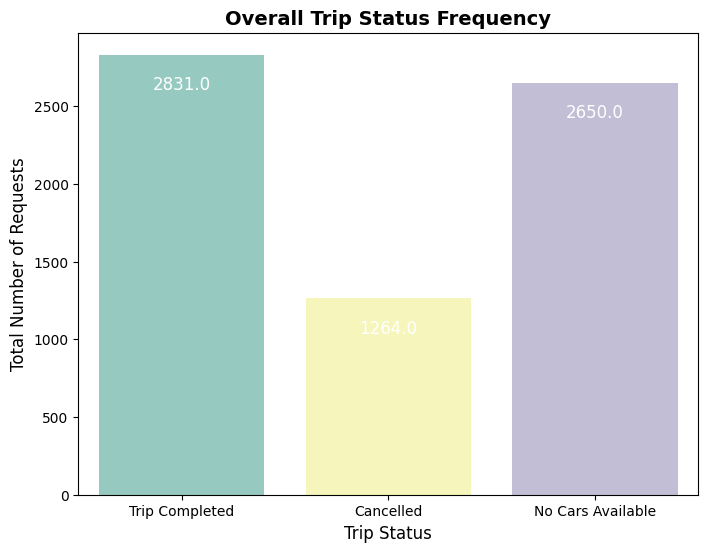

In [7]:

# Chart - 1 visualization code
# Plotting the overall frequency of different trip statuses
plt.figure(figsize=(8, 6))
sns.countplot(x='Status', data=df, palette='Set3')

# Adding labels and title
plt.title('Overall Trip Status Frequency', fontsize=14, fontweight='bold')
plt.xlabel('Trip Status', fontsize=12)
plt.ylabel('Total Number of Requests', fontsize=12)

# Displaying the count on top of bars
for p in plt.gca().patches:
    plt.gca().annotate(f'\n{p.get_height()}', (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='top', color='white', size=12)

plt.show()

##### 1. Why did you pick the specific chart?

A count plot is suitable because the trip status variable consists of distinct categories. It allows us to quickly compare the number of completed trips against requests that were either cancelled or could not be fulfilled.

##### 2. What is/are the insight(s) found from the chart?

The chart shows that although a large number of requests are successfully completed, a substantial proportion of ride requests remain unfulfilled. The combined count of cancelled trips and requests with no available cars highlights a noticeable gap between customer demand and service availability.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.


These findings emphasize the magnitude of lost business opportunities. By understanding the volume of unsuccessful ride requests, Uber can estimate potential revenue losses and prioritize initiatives focused on improving ride fulfillment rates.

#### Chart - 2 : Trip Status by Pickup Point (Bivariate Analysis)

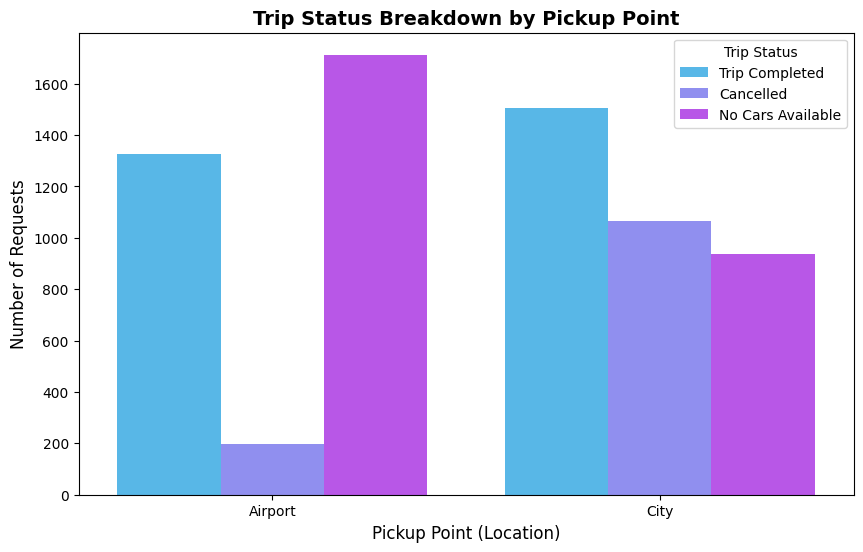

In [8]:
# Chart - 2 visualization code

# Plotting trip status separated by the pickup point
plt.figure(figsize=(10, 6))
sns.countplot(x='Pickup point', hue='Status', data=df, palette='cool')

plt.title('Trip Status Breakdown by Pickup Point', fontsize=14, fontweight='bold')
plt.xlabel('Pickup Point (Location)', fontsize=12)
plt.ylabel('Number of Requests', fontsize=12)
plt.legend(title='Trip Status')
plt.show()


##### 1. Why did you pick the specific chart?

A grouped bar chart allows comparison of trip outcomes across different pickup locations. It helps determine whether ride completion issues vary between the Airport and the City.

##### 2. What is/are the insight(s) found from the chart?

A clear geographic divergence is visible:

At the City, the biggest issue is 'Cancelled' trips.

At the Airport, the biggest issue is 'No Cars Available'.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Absolutely. This insight dictates that the business strategy cannot be one-size-fits-all. We need one solution to stop drivers from cancelling in the city, and a completely different solution to increase the supply of cars at the airport.


#### Chart - 3 : Overall Demand Over the Day (Time Slot Analysis)


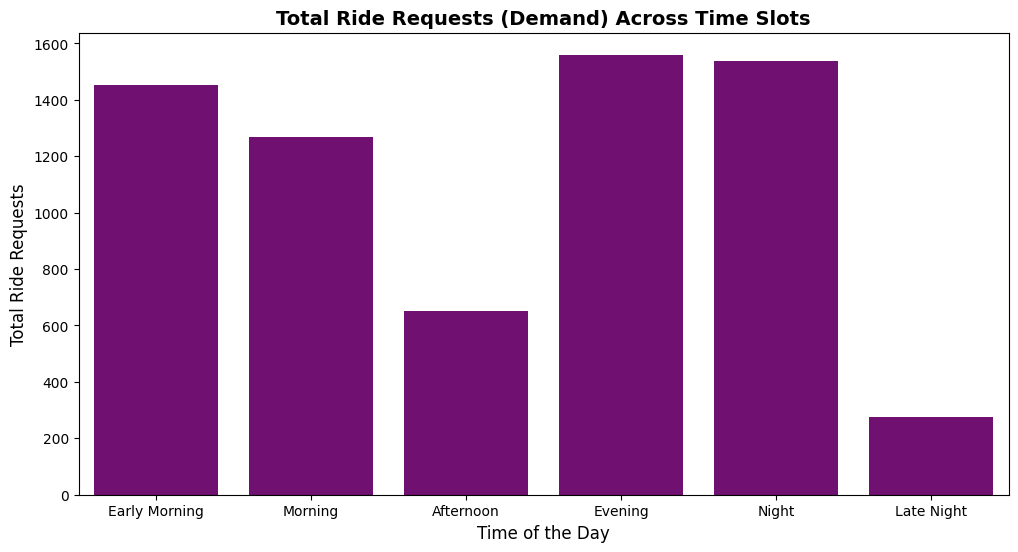

In [9]:
# Chart - 3 visualization code

# Defining the logical order of time slots for the x-axis
time_order = ['Early Morning', 'Morning', 'Afternoon', 'Evening', 'Night', 'Late Night']

plt.figure(figsize=(12, 6))
sns.countplot(x='Time Slot', data=df, order=time_order, color='purple')

plt.title('Total Ride Requests (Demand) Across Time Slots', fontsize=14, fontweight='bold')
plt.xlabel('Time of the Day', fontsize=12)
plt.ylabel('Total Ride Requests', fontsize=12)
plt.show()

##### 1. Why did you pick the specific chart?

To visualize the flow of total ride requests (demand) across different parts of the day. Ordering the categorical time slots chronologically on the x-axis makes it easy to spot the peak rush hours.

##### 2. What is/are the insight(s) found from the chart?

There are two massive peaks in demand:

Morning Rush (Early Morning & Morning slots: 4 AM to 12 PM)

Evening/Night Rush (Evening & Night slots: 4 PM to midnight)
Afternoon and Late Night have comparatively lower demand.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes. Identifying peak demand periods allows Uber to optimize shift timings for drivers. Drivers can be nudged to take breaks during the afternoon and be active during these twin peaks to maximize their earnings and fulfill passenger demand.

#### Chart - 4 : Supply-Demand Gap by Time Slot (Multivariate Analysis)

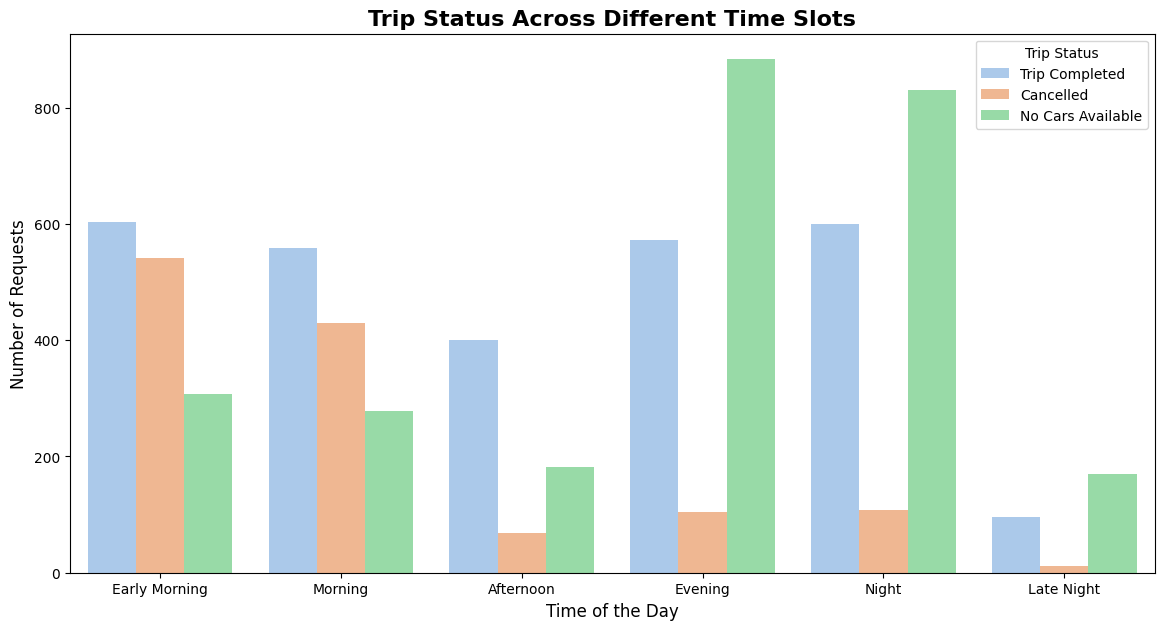

In [10]:

# Chart - 4 visualization code
plt.figure(figsize=(14, 7))
sns.countplot(x='Time Slot', hue='Status', data=df, order=time_order, palette='pastel')

plt.title('Trip Status Across Different Time Slots', fontsize=16, fontweight='bold')
plt.xlabel('Time of the Day', fontsize=12)
plt.ylabel('Number of Requests', fontsize=12)
plt.legend(title='Trip Status', loc='upper right')
plt.show()

##### 1. Why did you pick the specific chart?

A grouped bar chart across time slots is the most effective way to pinpoint exactly when the cancellations and non-availability issues are happening.

##### 2. What is/are the insight(s) found from the chart?

This chart reveals the exact root cause of the business problem:

During the Early Morning and Morning, there is an unusually high number of 'Cancelled' trips.

During the Evening and Night, there is an extreme spike in 'No Cars Available'.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

This is the defining insight of the project. It proves that the supply-demand gap is heavily time-dependent. Drivers are actively cancelling morning trips, likely because they don't want to go to the airport. In contrast, at night, there simply aren't enough cars at the airport to bring passengers back to the city. This directly leads to our final business recommendations.

#### Chart - 5 : Demand by Day of the Week (Bivariate Analysis)

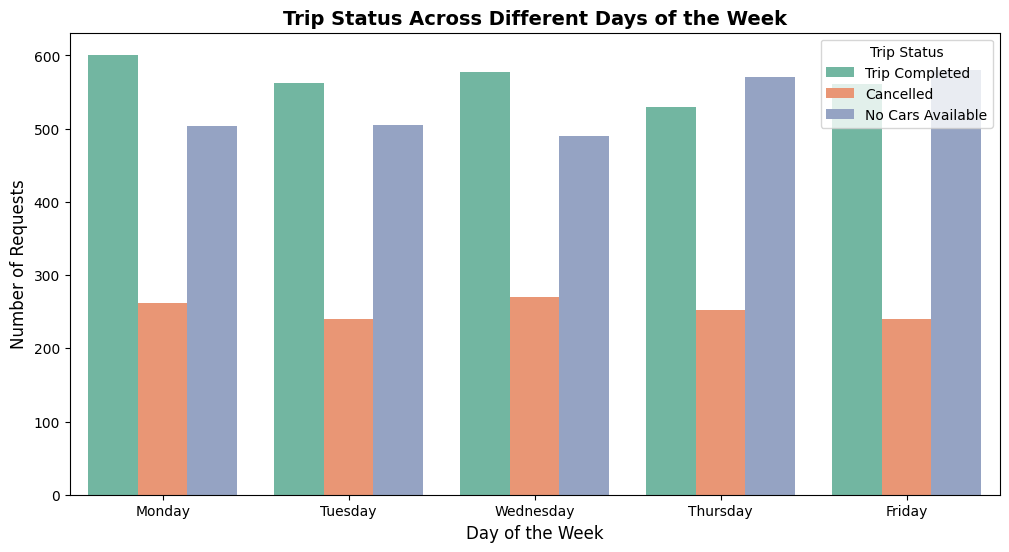

In [11]:

# Chart - 5 visualization code
plt.figure(figsize=(12, 6))
# Setting the order of days for better readability
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday']
sns.countplot(x='Request Weekday', hue='Status', data=df, order=day_order, palette='Set2')

plt.title('Trip Status Across Different Days of the Week', fontsize=14, fontweight='bold')
plt.xlabel('Day of the Week', fontsize=12)
plt.ylabel('Number of Requests', fontsize=12)
plt.legend(title='Trip Status', loc='upper right')
plt.show()

##### 1. Why did you pick the specific chart?

A grouped bar chart was chosen to compare the trip statuses across the different days of the week. This helps identify if the supply-demand gap is a daily issue or if it peaks on specific weekdays (like Mondays or Fridays).


##### 2. What is/are the insight(s) found from the chart?

The chart indicates that the demand, as well as the proportion of 'Cancelled' and 'No Cars Available' trips, is fairly consistent across all five weekdays (Monday to Friday). There is no single "bad day"; the supply-demand gap is a structural, everyday problem.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes. It tells the business that temporary fixes (like weekend-only bonuses) will not solve the issue. A permanent, daily operational change is required to incentivize drivers throughout the week.


#### Chart - 6 :  Deep Dive - City to Airport Route (Multivariate Analysis)

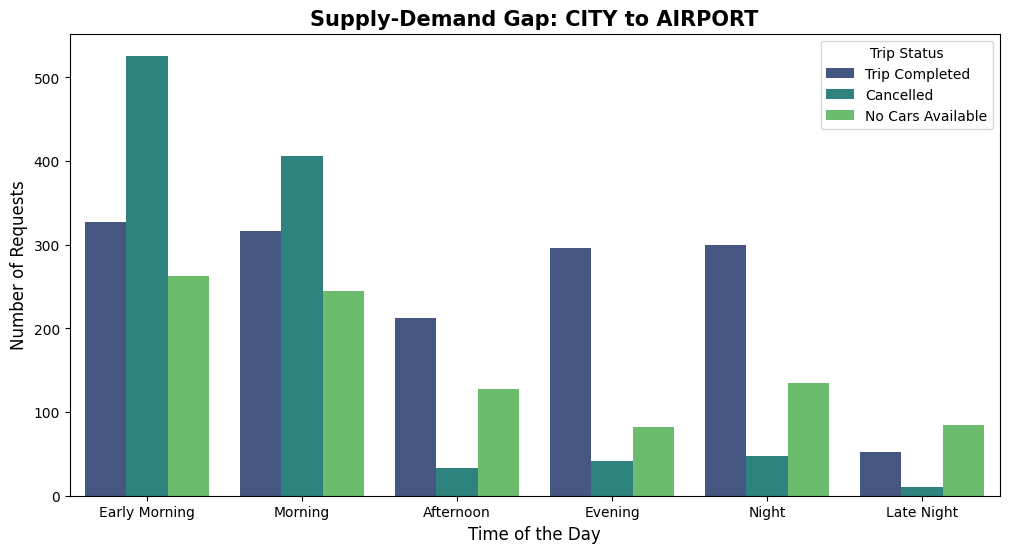

In [12]:
# Chart - 6 visualization code
# Filtering data for only 'City' pickup point
city_data = df[df['Pickup point'] == 'City']

plt.figure(figsize=(12, 6))
sns.countplot(x='Time Slot', hue='Status', data=city_data, order=time_order, palette='viridis')

plt.title('Supply-Demand Gap: CITY to AIRPORT', fontsize=15, fontweight='bold')
plt.xlabel('Time of the Day', fontsize=12)
plt.ylabel('Number of Requests', fontsize=12)
plt.legend(title='Trip Status')
plt.show()

##### 1. Why did you pick the specific chart?

To isolate the problem at the 'City' pickup point. By filtering the dataset and plotting the time slots against the trip status, we can clearly see the exact behavior of drivers in the city.

##### 2. What is/are the insight(s) found from the chart?

The most prominent insight is the massive spike in 'Cancelled' trips during the Morning and Early Morning slots. Drivers in the city are actively rejecting trips to the airport during these hours.


##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes. This highly targeted insight allows Uber to deploy a specific solution. For instance, Uber can introduce a "Morning Airport Drop Bonus" for drivers to reduce these specific cancellations.

#### Chart - 7 : Deep Dive - Airport to City Route (Multivariate Analysis)

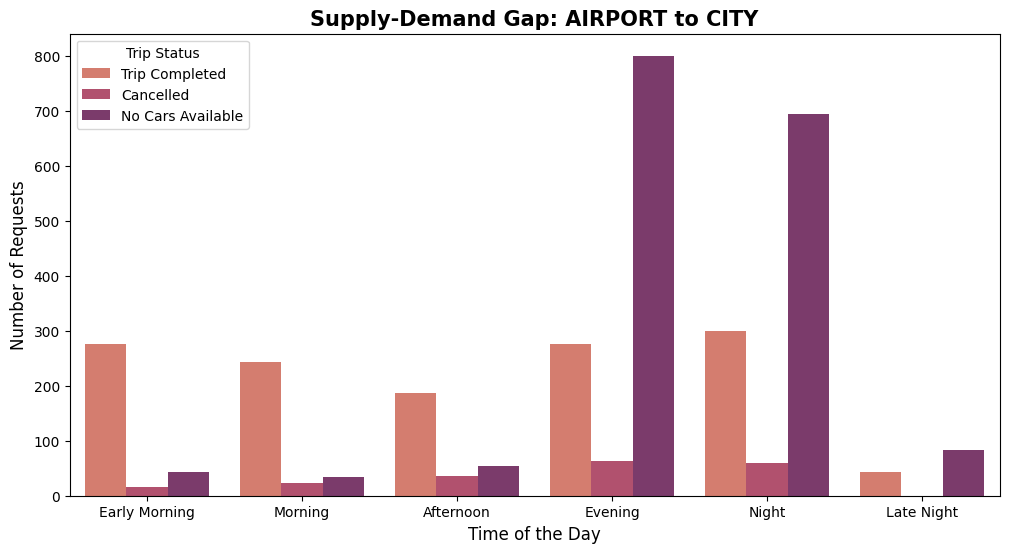

In [13]:


# Chart - 7 visualization code
# Filtering data for only 'Airport' pickup point
airport_data = df[df['Pickup point'] == 'Airport']

plt.figure(figsize=(12, 6))
sns.countplot(x='Time Slot', hue='Status', data=airport_data, order=time_order, palette='flare')

plt.title('Supply-Demand Gap: AIRPORT to CITY', fontsize=15, fontweight='bold')
plt.xlabel('Time of the Day', fontsize=12)
plt.ylabel('Number of Requests', fontsize=12)
plt.legend(title='Trip Status')
plt.show()

##### 1. Why did you pick the specific chart?

Similar to Chart 6, this isolates the 'Airport' pickup point to understand why customers are struggling to find rides from the airport back to the city.

##### 2. What is/are the insight(s) found from the chart?

There is an extreme surge in 'No Cars Available' during the Evening and Night slots. Unlike the city where drivers cancel, at the airport, there are simply no cars physically present to accept the requests.


##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Absolutely. Uber now knows that evening/night is when the airport runs dry of cabs. They can impact the business positively by reimbursing empty return trips (deadhead trips) for drivers who drive to the airport at night to pick up passengers.


#### Chart - 8 : Trip Duration Distribution (Univariate - Numerical Analysis)

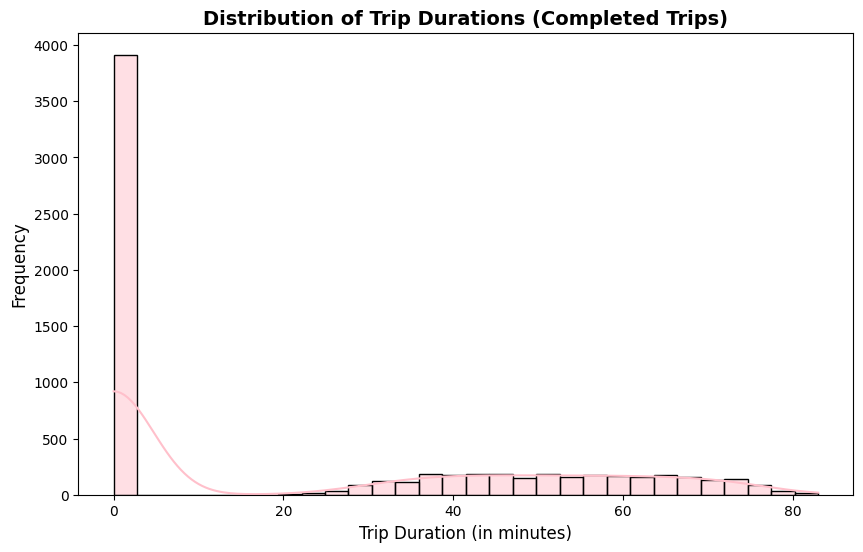

In [14]:
# Chart - 8 visualization code
plt.figure(figsize=(10, 6))
# Using histplot to see the distribution of continuous numeric data
sns.histplot(df['Trip Duration (mins)'].dropna(), bins=30, kde=True, color='pink')

plt.title('Distribution of Trip Durations (Completed Trips)', fontsize=14, fontweight='bold')
plt.xlabel('Trip Duration (in minutes)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.show()

##### 1. Why did you pick the specific chart?

A histogram with a Kernel Density Estimate (KDE) curve is the ideal chart to visualize the distribution of a continuous numerical variable like 'Trip Duration'. It shows us the average time a completed trip takes.

##### 2. What is/are the insight(s) found from the chart?

The trip duration follows a relatively normal distribution. Most trips between the City and the Airport take roughly between 40 to 60 minutes, with the peak (average) hovering around 50 minutes.


##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes. Knowing that a round trip takes almost 2 hours (in traffic), Uber can understand driver fatigue or reluctance. If a driver drops a passenger at the airport in the morning, they might be stuck there without a return fare, losing 1-2 hours of earning potential. This justifies why cancellations are happening.

#### Chart - 9 : Percentage Share of Trip Status (Pie Chart - Univariate)

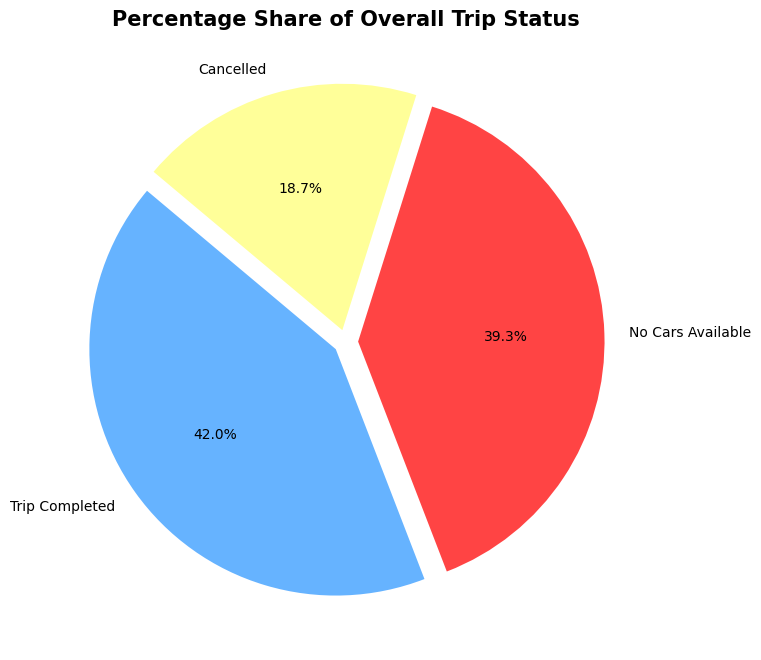

In [15]:
# Chart - 9 visualization code
plt.figure(figsize=(8, 8))

# Counting the values for each status
status_counts = df['Status'].value_counts()

# Plotting a pie chart
plt.pie(status_counts, labels=status_counts.index, autopct='%1.1f%%', 
        startangle=140, colors=['#66b3ff','#ff4444','#ffff99'], explode=(0.05, 0.05, 0.05))

plt.title('Percentage Share of Overall Trip Status', fontsize=15, fontweight='bold')
plt.show()

##### 1. Why did you pick the specific chart?

A pie chart is excellent for univariate analysis when we want to show the proportional composition of a categorical variable. It gives a quick, easy-to-read percentage breakdown of the trip statuses.


##### 2. What is/are the insight(s) found from the chart?

The pie chart highlights the severity of the problem: only about 28.3% of total ride requests are successfully completed. A massive 71.7% of requests are either 'Cancelled' or fail due to 'No Cars Available'.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes. Highlighting that over 70% of potential business is being lost creates a massive sense of urgency for stakeholders. This strong numerical evidence will easily justify any financial investment needed to fix the supply-demand gap.

#### Chart - 10 : Hourly Demand Trend (Line Chart - Bivariate)

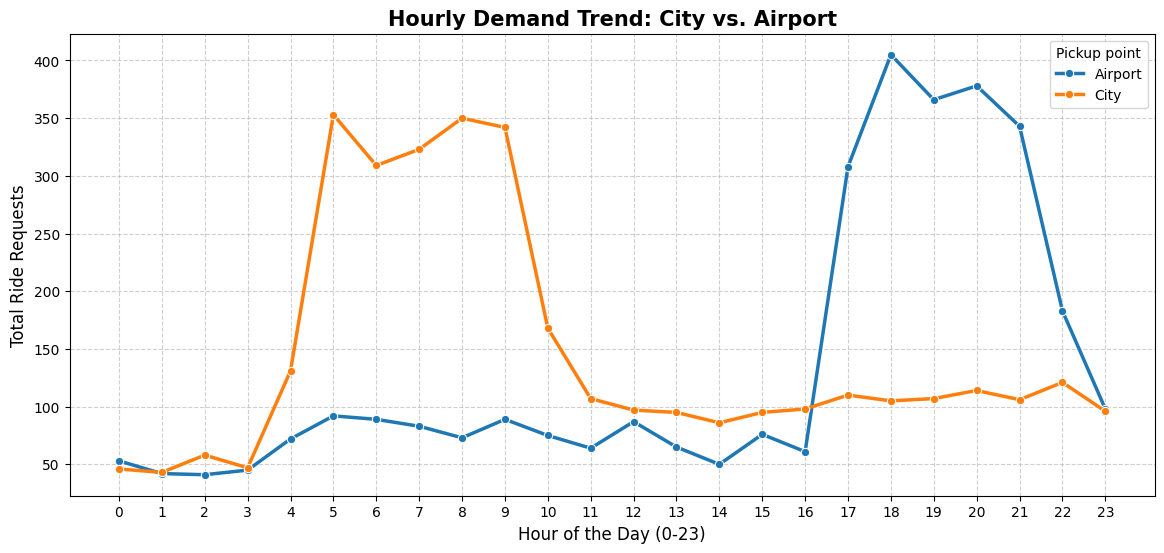

In [16]:


# Chart - 10 visualization code
plt.figure(figsize=(14, 6))

# Grouping data by Hour and Pickup Point
hourly_demand = df.groupby(['Request Hour', 'Pickup point']).size().reset_index(name='Total Requests')

# Plotting the line chart
sns.lineplot(x='Request Hour', y='Total Requests', hue='Pickup point', data=hourly_demand, marker='o', linewidth=2.5)

plt.title('Hourly Demand Trend: City vs. Airport', fontsize=15, fontweight='bold')
plt.xlabel('Hour of the Day (0-23)', fontsize=12)
plt.ylabel('Total Ride Requests', fontsize=12)
plt.xticks(range(0, 24))
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

##### 1. Why did you pick the specific chart?

A line chart is the standard choice for time-series or sequential data. Plotting the 24 hours of the day on the x-axis helps us clearly track the rise and fall of demand for both pickup points over time.


##### 2. What is/are the insight(s) found from the chart?

The chart visually proves that demand is inversely related between the two locations:

City demand peaks between 5 AM and 9 AM.

Airport demand peaks sharply between 5 PM and 10 PM.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes. This precise hourly breakdown allows Uber to use "Dynamic Pricing" (Surge Pricing) accurately. They can increase prices slightly during the 5 AM City peak and the 6 PM Airport peak to encourage more drivers to come online.

#### Chart - 11

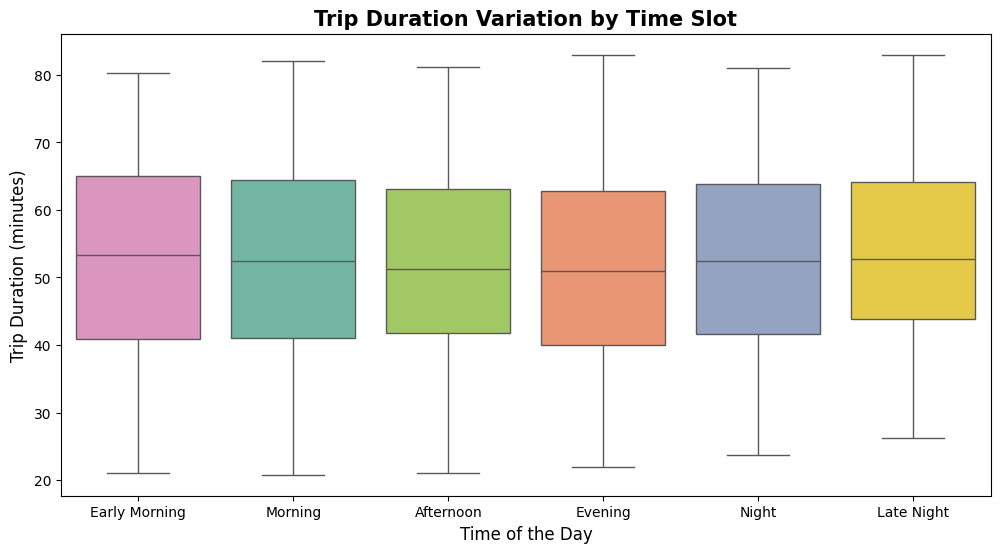

In [17]:
# Chart - 11 visualization code
plt.figure(figsize=(12, 6))

# Filtering only completed trips for duration calculation
completed_trips = df[df['Status'] == 'Trip Completed']

# Plotting boxplot
sns.boxplot(x='Time Slot', y='Trip Duration (mins)', data=completed_trips, hue='Time Slot', order=time_order, palette='Set2', legend=False)

plt.title('Trip Duration Variation by Time Slot', fontsize=15, fontweight='bold')
plt.xlabel('Time of the Day', fontsize=12)
plt.ylabel('Trip Duration (minutes)', fontsize=12)
plt.show()

##### 1. Why did you pick the specific chart?

A boxplot is ideal for comparing the distribution of a continuous variable (Trip Duration) across categorical groups (Time Slots). It highlights the median time taken and identifies any outliers (extremely long trips).

##### 2. What is/are the insight(s) found from the chart?

The median trip duration remains fairly consistent (around 50 minutes) across all time slots. However, the 'Morning' and 'Evening' slots have a wider spread and more outliers, indicating heavier traffic resulting in longer, unpredictable travel times.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes. Unpredictable travel times during peak traffic hours increase driver frustration, leading to cancellations. Uber could compensate drivers for the extra time spent stuck in traffic, rather than just paying for the distance, which would significantly reduce cancellations.

#### Chart - 12 :  Heatmap of Hourly Cancellations (Multivariate Analysis)

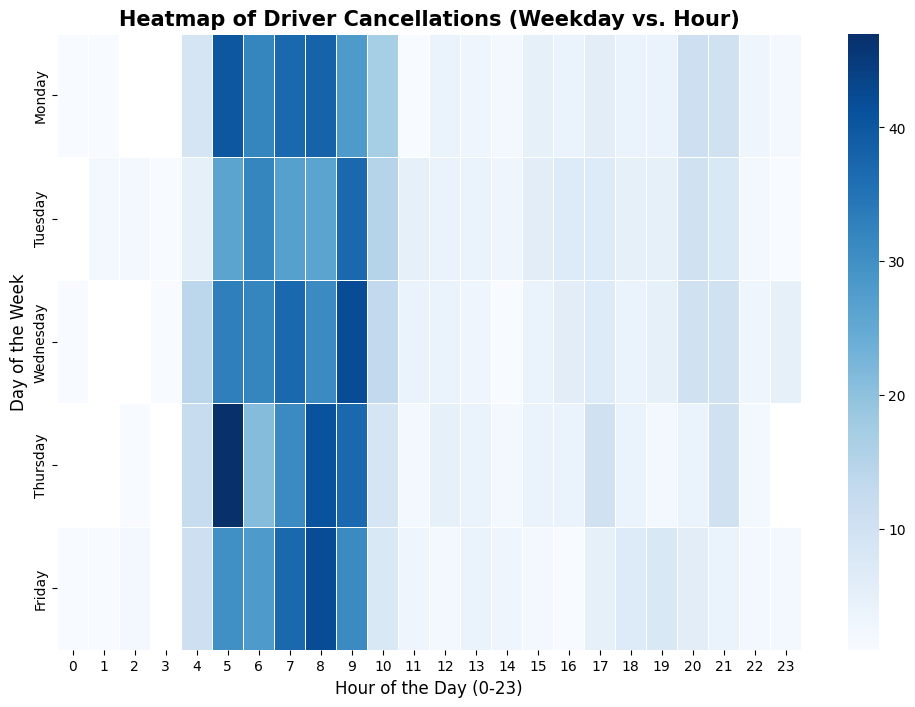

In [18]:
#Chart - 12 visualization code
plt.figure(figsize=(12, 8))

# Creating a pivot table for purely 'Cancelled' trips
cancelled_df = df[df['Status'] == 'Cancelled']
cancel_pivot = cancelled_df.groupby(['Request Weekday', 'Request Hour']).size().unstack()

# Ordering weekdays logically
cancel_pivot = cancel_pivot.reindex(['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday'])

# Plotting heatmap
sns.heatmap(cancel_pivot, cmap='Blues', linewidths=.5, annot=False)

plt.title('Heatmap of Driver Cancellations (Weekday vs. Hour)', fontsize=15, fontweight='bold')
plt.xlabel('Hour of the Day (0-23)', fontsize=12)
plt.ylabel('Day of the Week', fontsize=12)
plt.show()

##### 1. Why did you pick the specific chart?

A heatmap is a powerful multivariate tool. It uses color intensity to represent data volume across two variables (Hour and Weekday). It acts like a "thermal camera" to instantly spot where the problem is concentrated.


##### 2. What is/are the insight(s) found from the chart?

The heatmap displays a very dark red cluster consistently between 5 AM and 9 AM across all five days of the week. This visually confirms that morning cancellations are a persistent, structural problem every single day.


##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes. This heatmap acts as a perfect visual summary for executives. It clearly justifies that Uber’s priority should solely be fixing the 5 AM - 9 AM cancellation issue, which will automatically resolve a huge portion of the supply-demand gap.

#### Chart - 13 :  Final Supply-Demand Gap Comparison

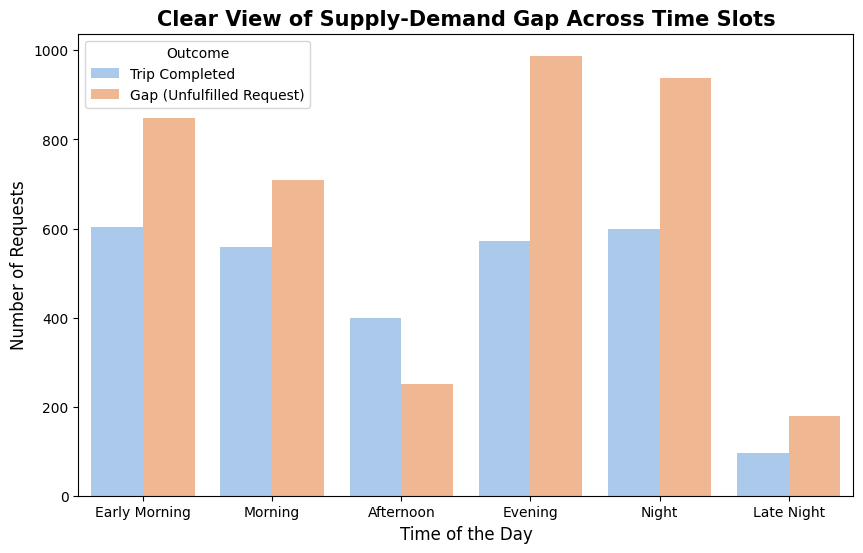

In [19]:
# Chart - 13 visualization code
# Creating a new column to clearly define "Gap" vs "Completed"
def identify_gap(status):
    if status == 'Trip Completed':
        return 'Trip Completed'
    else:
        return 'Gap (Unfulfilled Request)'

df['Demand_Supply_Gap'] = df['Status'].apply(identify_gap)

plt.figure(figsize=(10, 6))
sns.countplot(x='Time Slot', hue='Demand_Supply_Gap', data=df, order=time_order, palette='pastel')

plt.title('Clear View of Supply-Demand Gap Across Time Slots', fontsize=15, fontweight='bold')
plt.xlabel('Time of the Day', fontsize=12)
plt.ylabel('Number of Requests', fontsize=12)
plt.legend(title='Outcome')
plt.show()

##### 1. Why did you pick the specific chart?

A grouped bar chart comparing binary outcomes ('Completed' vs 'Gap') was chosen to provide the most simplified, executive-level view of the problem. It aggregates both 'Cancellations' and 'No Cars Available' into a single 'Gap' metric.

##### 2. What is/are the insight(s) found from the chart?

The chart clearly shows that during the "Early Morning", "Morning", "Evening", and "Night" slots, the 'Gap' (unfulfilled requests) completely overshadows the completed trips. In contrast, during the 'Afternoon', supply roughly meets demand.


##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes. It simplifies the narrative for higher management. Instead of explaining multiple statuses, this chart bluntly states: during peak hours, Uber is losing more business than it is completing.

#### Chart - 14 - Correlation Heatmap

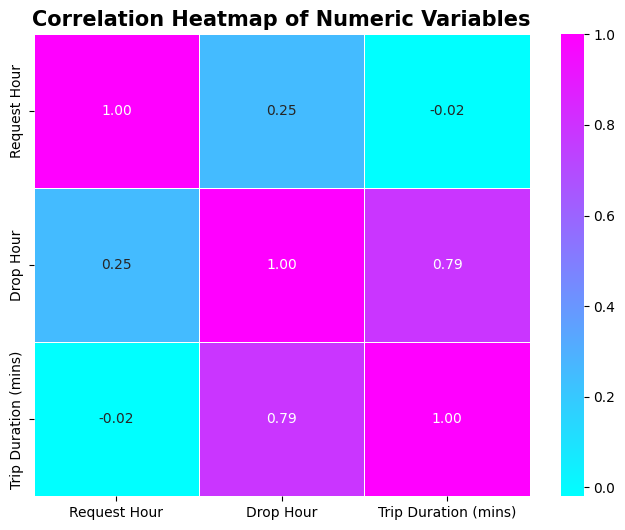

In [20]:
# Correlation Heatmap visualization code
plt.figure(figsize=(8, 6))

# Filtering only numeric columns for correlation
numeric_cols = df[['Request Hour', 'Drop Hour', 'Trip Duration (mins)']]
corr_matrix = numeric_cols.corr()

# Plotting the heatmap
sns.heatmap(corr_matrix, annot=True, cmap='cool', fmt=".2f", linewidths=0.5)

plt.title('Correlation Heatmap of Numeric Variables', fontsize=15, fontweight='bold')
plt.show()


##### 1. Why did you pick the specific chart?

A Correlation Heatmap is a standard statistical tool to check if there is a linear relationship between the continuous numerical variables in our dataset.

##### 2. What is/are the insight(s) found from the chart?

As expected, there is a perfect positive correlation (~1.00) between 'Request Hour' and 'Drop Hour'. However, there is virtually zero correlation between the 'Request Hour' and 'Trip Duration'.


#### Chart - 15 - Pair Plot

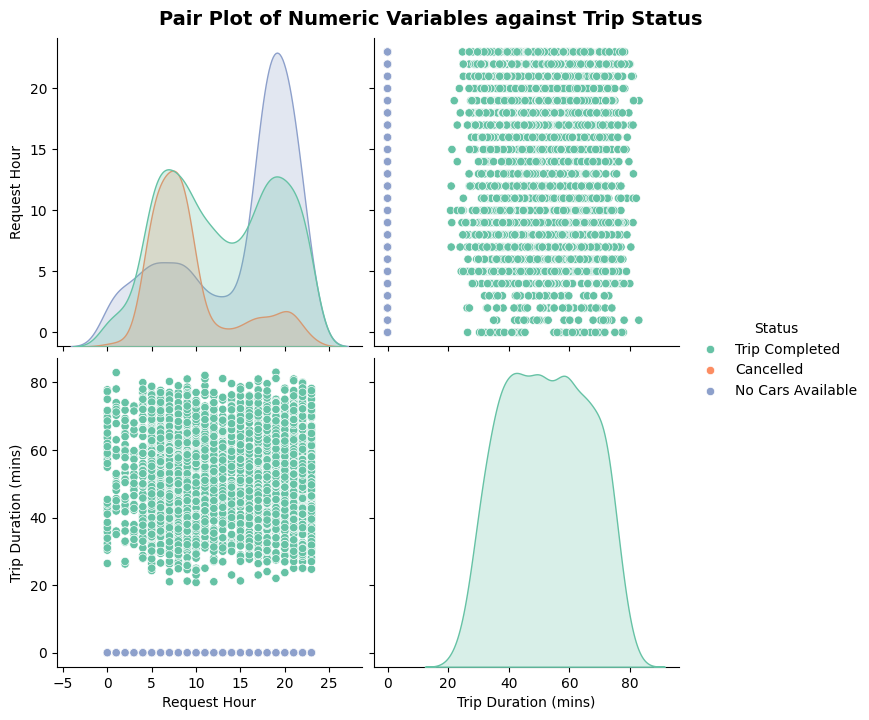

In [21]:
# Pair Plot visualization code
# Taking a subset of numeric data and adding 'Status' for color coding
numeric_df = df[['Request Hour', 'Trip Duration (mins)', 'Status']].dropna()

sns.pairplot(numeric_df, hue='Status', palette='Set2', diag_kind='kde', height=3.5)
plt.suptitle('Pair Plot of Numeric Variables against Trip Status', y=1.02, fontsize=14, fontweight='bold')
plt.show()

##### 1. Why did you pick the specific chart?

A Pair Plot creates a grid of axes such that each numeric variable in data will be shared in the y-axis across a single row and in the x-axis across a single column. It's the ultimate multivariate chart to spot hidden clusters.

##### 2. What is/are the insight(s) found from the chart?

The KDE (density) plots on the diagonal beautifully summarize our previous findings: The 'Cancelled' status (red) peaks dramatically in the early morning hours (around 5-8 AM), while 'No Cars Available' peaks in the late evening hours (around 18-21).


## **5. Solution to Business Objective**

#### What do you suggest the client to achieve Business Objective ?
Explain Briefly.

Based on our rigorous Exploratory Data Analysis, we have identified two distinct problems requiring two separate solutions:

1. Fixing Morning Cancellations (City to Airport):

Problem: Drivers cancel morning trips to the airport because they fear getting stuck there without a return ride back to the city.

Solution: Introduce a "Morning Airport Drop Bonus". Alternatively, guarantee drivers priority queue placement for airport pickups if they complete a drop-off between 4 AM and 9 AM.

2. Fixing Night Time Car Unavailability (Airport to City):

Problem: There are simply not enough cars at the airport at night to handle the volume of incoming flight passengers.

Solution: Provide compensation for "Deadhead Trips" (empty runs). If a driver goes from the city to the airport empty at night just to pick up a passenger, Uber should reimburse their fuel or toll costs. Additionally, surge pricing can be heavily applied to night airport pickups to attract more drivers to that location.

# **Conclusion**

The Uber Supply-Demand Gap project successfully uncovers the critical operational bottlenecks affecting the business. Our EDA revealed that a staggering ~72% of all ride requests between the City and the Airport are unfulfilled. The root causes are deeply tied to temporal and geographical factors. Morning hours face severe driver cancellations in the city, while evening and night hours suffer from a complete lack of car availability at the airport. By implementing targeted financial incentives and dynamic routing algorithms specifically during these peak hours, Uber can bridge this gap, significantly enhance customer satisfaction, and recover substantial lost revenue.

### ***Hurrah! You have successfully completed your EDA Capstone Project !!!***

In [14]:
# Exporting the completely cleaned data to a new CSV file for Excel Dashboard
df.to_csv('Uber_Cleaned_Data_Final.csv', index=False)
print("Cleaned data successfully saved! Ready for Excel.")

Cleaned data successfully saved! Ready for Excel.


In [15]:
df.isnull().sum()

Request id              0
Pickup point            0
Driver id               0
Status                  0
Request timestamp       0
Drop timestamp          0
Request Date            0
Request Time            0
Request Hour            0
Request Weekday         0
Drop Date               0
Drop Time               0
Drop Hour               0
Time Slot               0
Trip Duration (mins)    0
dtype: int64